# Training


Install packages


In [1]:
!uv pip install -q boto3==1.42.68 catboost==1.2.10 imbalanced-learn==0.14.1 lightgbm==4.6.0 matplotlib==3.10.8 mlflow==3.10.1 mlflow-skinny==3.10.1 mlflow-tracing==3.10.1 numpy==2.4.3 pandas==2.3.3 pyarrow==23.0.1 scikit-learn==1.8.0 seaborn==0.13.2 shap==0.51.0 xgboost==3.2.0 optuna==4.7.0 optuna-integration==4.7.0

In [2]:
!uv pip freeze | grep -E "scikit-learn|xgboost|lightgbm|catboost|mlflow|boto3|pyarrow|pandas|numpy|matplotlib|seaborn|shap|imbalanced-learn|optuna|optuna-integration"

boto3==1.42.68
catboost==1.2.10
imbalanced-learn==0.14.1
lightgbm==4.6.0
matplotlib==3.10.8
mlflow==3.10.1
mlflow-skinny==3.10.1
mlflow-tracing==3.10.1
numpy==2.4.3
optuna==4.7.0
optuna-integration==4.7.0
pandas==2.3.3
pyarrow==23.0.1
scikit-learn==1.8.0
seaborn==0.13.2
shap==0.51.0
xgboost==3.2.0


Import packages


In [ ]:
import io
import pickle
import time
import warnings
from typing import Any, Dict, Tuple, Union

import boto3
import lightgbm
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
import shap
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from optuna.samplers import TPESampler
from optuna.trial import Trial
from sklearn.base import BaseEstimator
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier

In [4]:
warnings.filterwarnings("ignore")

S3_ENDPOINT = "http://localstack:4566"
BUCKET = "data-lake"
PREFIX = "gold/credit_risk/features/"
TARGET = "serious_dlqin2yrs"
RANDOM_STATE: int = 42

MLFLOW_TRACKING_URI = "http://mlflow:5000"
EXPERIMENT_NAME = "credit_risk_training"

s3_client = boto3.client("s3")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(EXPERIMENT_NAME)

optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"Experiment: {exp.name} (id={exp.experiment_id})")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Artifact store: {exp.artifact_location}")

Experiment: credit_risk_training (id=2)
Tracking URI: http://mlflow:5000
Artifact store: mlflow-artifacts:/2


## Evaluation Helper Functions


In [5]:
def ks_statistic(
    y_true: Union[np.ndarray, pd.Series], y_prob: Union[np.ndarray, pd.Series]
) -> float:
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, y_prob)
    return float(np.max(true_positive_rate - false_positive_rate))


def gini(auc: float) -> float:
    return 2.0 * auc - 1.0


def evaluate(
    model: BaseEstimator,
    X: Union[np.ndarray, pd.DataFrame],
    y: Union[np.ndarray, pd.Series],
    split_name: str,
    log_to_mlflow: bool = True,
) -> Dict[str, float]:

    # Get probabilities for the positive class
    y_prob: np.ndarray = model.predict_proba(X)[:, 1]

    auc: float = float(roc_auc_score(y, y_prob))
    ks: float = ks_statistic(y, y_prob)
    pr_auc: float = float(average_precision_score(y, y_prob))
    g: float = gini(auc)

    metrics: Dict[str, float] = {
        f"{split_name}_auc_roc": round(auc, 4),
        f"{split_name}_ks": round(ks, 4),
        f"{split_name}_gini": round(g, 4),
        f"{split_name}_pr_auc": round(pr_auc, 4),
    }

    if log_to_mlflow:
        mlflow.log_metrics(metrics)

    print(
        f"  [{split_name}] AUC={auc:.4f} | KS={ks:.4f} | Gini={g:.4f} | PR-AUC={pr_auc:.4f}"
    )

    return metrics


def cv_score(
    model: BaseEstimator,
    X: Union[np.ndarray, pd.DataFrame],
    y: Union[np.ndarray, pd.Series],
    n_splits: int = 5,
) -> Tuple[float, float]:

    cv: StratifiedKFold = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    # cross_val_score returns a numpy array of scores for each fold
    scores: np.ndarray = cross_val_score(
        model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1
    )

    mean_score: float = float(scores.mean())
    std_score: float = float(scores.std())

    print(f"  [CV-{n_splits}fold] AUC={mean_score:.4f} ± {std_score:.4f}")

    return mean_score, std_score

## Load Gold from S3


In [ ]:
keys = [
    o["Key"]
    for o in s3_client.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX).get(
        "Contents", []
    )
    if o["Key"].endswith(".parquet")
]

df = pd.concat(
    [
        pd.read_parquet(
            io.BytesIO(
                s3_client.get_object(Bucket=BUCKET, Key=k)["Body"].read()
            )
        )
        for k in keys
    ],
    ignore_index=True,
)

# drop partition column written by Spark — not a feature
df = df.drop(columns=["ingestion_date"], errors="ignore")

df.head()

,serious_dlqin2yrs,revolving_utilization_of_unsecured_lines,age,number_of_time30_59_days_past_due_not_worse,debt_ratio,monthly_income,number_of_open_credit_lines_and_loans,number_of_times90_days_late,number_real_estate_loans_or_lines,number_of_time60_89_days_past_due_not_worse,number_of_dependents,monthly_income_is_missing,number_of_dependents_is_missing,delinquency_score,debt_to_income_ratio,unsecured_to_total_lines_ratio,age_risk_bucket,has_any_delinquency
0,0,1.000000,49,0,2883.000000,0.0,9,0,2,0,1.0,0,0,0.0,NaN,0.777778,middle,0
1,1,1.000000,44,2,0.547762,6500.0,13,0,4,0,2.0,0,0,2.0,0.000084,0.692308,middle,1
2,0,0.001102,58,0,0.396173,3500.0,6,0,2,0,0.0,0,0,0.0,0.000113,0.666667,senior,0
3,0,0.018978,61,0,1129.000000,NaN,9,0,1,0,0.0,1,0,0.0,NaN,0.888889,senior,0
4,0,0.047006,40,0,0.183151,5388.0,12,0,0,0,0.0,0,0,0.0,0.000034,1.000000,middle,0


In [7]:
print(f"Shape: {df.shape}\n")
print(f"Columns: {df.columns.tolist()}\n")
print(f"\nTarget distribution:\n{df[TARGET].value_counts()}\n")
print(f"Default rate: {df[TARGET].mean()*100:.2f}%\n")

Shape: (149390, 18)

Columns: ['serious_dlqin2yrs', 'revolving_utilization_of_unsecured_lines', 'age', 'number_of_time30_59_days_past_due_not_worse', 'debt_ratio', 'monthly_income', 'number_of_open_credit_lines_and_loans', 'number_of_times90_days_late', 'number_real_estate_loans_or_lines', 'number_of_time60_89_days_past_due_not_worse', 'number_of_dependents', 'monthly_income_is_missing', 'number_of_dependents_is_missing', 'delinquency_score', 'debt_to_income_ratio', 'unsecured_to_total_lines_ratio', 'age_risk_bucket', 'has_any_delinquency']


Target distribution:
serious_dlqin2yrs
0    139381
1     10009
Name: count, dtype: int64

Default rate: 6.70%



## Stratified split


In [8]:
X = df.drop(columns=TARGET)
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

for name, ys in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:<7}: {len(ys):>7} rows | default rate: {ys.mean() * 100}")

train  :  104573 rows | default rate: 6.699626098514913
val    :   22408 rows | default rate: 6.698500535523028
test   :   22409 rows | default rate: 6.702664108170824


## Preprocessing Pipeline


In [ ]:
# Columns with nulls that need imputation
NUMERIC_WITH_NULLS = [
    "monthly_income",
    "number_of_dependents",
    "debt_to_income_ratio",
]

# All numeric features (impute + scale)
NUMERIC_FEATURES = [
    "revolving_utilization_of_unsecured_lines",
    "age",
    "number_of_time30_59_days_past_due_not_worse",
    "debt_ratio",
    "monthly_income",
    "number_of_open_credit_lines_and_loans",
    "number_of_times90_days_late",
    "number_real_estate_loans_or_lines",
    "number_of_time60_89_days_past_due_not_worse",
    "number_of_dependents",
    "monthly_income_is_missing",
    "number_of_dependents_is_missing",
    "delinquency_score",
    "debt_to_income_ratio",
    "unsecured_to_total_lines_ratio",
    "has_any_delinquency",
]

# Categorical features
CATEGORICAL_FEATURES = ["age_risk_bucket"]

# Age bucket order matters for ordinal encoding
AGE_BUCKET_ORDER = [["young", "middle", "senior", "elderly"]]

In [10]:
numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    [
        (
            "encoder",
            OrdinalEncoder(
                categories=AGE_BUCKET_ORDER,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        )
    ]
)

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ]
)

preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Preprocessor fitted on {len(X_train)} rows.")
print(f"Features after preprocessing: {X_train_proc.shape[1]}")
print(f"\nImputed medians (train):")

medians = preprocessor.named_transformers_["numeric"]["imputer"].statistics_
for fname, median in zip(NUMERIC_FEATURES, medians):
    if fname in NUMERIC_WITH_NULLS:
        print(f"  {fname}: {median:.4f}")

Preprocessor fitted on 104573 rows.
Features after preprocessing: 17

Imputed medians (train):
  monthly_income: 5400.0000
  number_of_dependents: 0.0000
  debt_to_income_ratio: 0.0000


## Model Definition


In [11]:
# scale_pos_weight = neg/pos = 13.9 (from EDA)
SPW = 13.9

MODELS = {
    "logistic_regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
    ),
    "xgboost": XGBClassifier(
        scale_pos_weight=SPW,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        # early_stopping_rounds=20,
        random_state=RANDOM_STATE,
    ),
    "lightgbm": LGBMClassifier(
        scale_pos_weight=SPW,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbosity=-1,
    ),
    "catboost": CatBoostClassifier(
        scale_pos_weight=SPW,
        iterations=300,
        depth=6,
        learning_rate=0.05,
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
}

print("Models defined:")
for name in MODELS:
    print(f" {name}")
print(f"\nscale_pos_weight = {SPW} (neg/pos ratio from EDA")

Models defined:
 logistic_regression
 xgboost
 lightgbm
 catboost

scale_pos_weight = 13.9 (neg/pos ratio from EDA


## Training


In [ ]:
results = {}

for model_name, model in MODELS.items():
    print(f"\n{'='*55}")
    print(f"Training: {model_name}")
    print(f"{'='*55}")

    with mlflow.start_run(run_name=model_name) as run:
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("train_size", len(X_train))
        mlflow.log_param("val_size", len(X_val))
        mlflow.log_param("scale_pos_weight", SPW)
        mlflow.log_param("random_state", RANDOM_STATE)

        cv_mean, cv_std = cv_score(model, X_train_proc, y_train)
        mlflow.log_metric("cv_auc_mean", round(cv_mean, 5))
        mlflow.log_metric("cv_auc_std", round(cv_std, 4))

        if model_name == "xgboost":
            model.fit(
                X_train_proc,
                y_train,
                eval_set=[(X_val_proc, y_val)],
                verbose=False,
            )

        else:
            model.fit(X_train_proc, y_train)

        train_metrics = evaluate(model, X_train_proc, y_train, "train")
        val_metrics = evaluate(model, X_val_proc, y_val, "val")

        mlflow.sklearn.log_model(model, name="model")
        run_id = run.info.run_id
        val_auc = val_metrics["val_auc_roc"]

        results[model_name] = {
            "run_id": run_id,
            "val_auc": val_auc,
            "val_ks": val_metrics["val_ks"],
            "val_gini": val_metrics["val_gini"],
            "cv_mean": cv_mean,
            "model": model,
        }

        print(f"  MLflow run_id: {run_id}")

print(f"\n{'='*55}")
print("RESULTS SUMMARY")
print(f"{'='*55}")
print(
    f"{'Model':<25} {'Val AUC':>9} {'Val KS':>8} {'Val Gini':>10} {'CV AUC':>9}"
)
print("-" * 65)
for name, r in sorted(
    results.items(), key=lambda x: x[1]["val_auc"], reverse=True
):
    print(
        f"{name:<25} {r['val_auc']:>9.4f} {r['val_ks']:>8.4f} {r['val_gini']:>10.4f} {r['cv_mean']:>9.4f}"
    )


Training: logistic_regression
  [CV-5fold] AUC=0.8498 ± 0.0041
  [train] AUC=0.8503 | KS=0.5488 | Gini=0.7006 | PR-AUC=0.3291
  [val] AUC=0.8505 | KS=0.5591 | Gini=0.7010 | PR-AUC=0.3197


2026/03/16 17:21:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/16 17:21:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  MLflow run_id: 40f78159a66f4217adbf735b64f4b8dc
🏃 View run logistic_regression at: http://mlflow:5000/#/experiments/2/runs/40f78159a66f4217adbf735b64f4b8dc
🧪 View experiment at: http://mlflow:5000/#/experiments/2

Training: xgboost
  [CV-5fold] AUC=0.8588 ± 0.0049
  [train] AUC=0.9191 | KS=0.6728 | Gini=0.8383 | PR-AUC=0.5180
  [val] AUC=0.8601 | KS=0.5770 | Gini=0.7203 | PR-AUC=0.3951


2026/03/16 17:22:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/16 17:22:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  MLflow run_id: bee7e3c5a0da4d3596135ee9aa2d1a71
🏃 View run xgboost at: http://mlflow:5000/#/experiments/2/runs/bee7e3c5a0da4d3596135ee9aa2d1a71
🧪 View experiment at: http://mlflow:5000/#/experiments/2

Training: lightgbm
  [CV-5fold] AUC=0.8611 ± 0.0050
  [train] AUC=0.9038 | KS=0.6446 | Gini=0.8075 | PR-AUC=0.4838
  [val] AUC=0.8632 | KS=0.5733 | Gini=0.7265 | PR-AUC=0.3977


2026/03/16 17:22:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/16 17:22:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  MLflow run_id: 2e560139f08c4185bf35379c9b69ba15
🏃 View run lightgbm at: http://mlflow:5000/#/experiments/2/runs/2e560139f08c4185bf35379c9b69ba15
🧪 View experiment at: http://mlflow:5000/#/experiments/2

Training: catboost
  [CV-5fold] AUC=0.8649 ± 0.0040
  [train] AUC=0.8806 | KS=0.6016 | Gini=0.7612 | PR-AUC=0.4338
  [val] AUC=0.8662 | KS=0.5848 | Gini=0.7324 | PR-AUC=0.4019


2026/03/16 17:23:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/16 17:23:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  MLflow run_id: 4ebea4e41e0644d290facb4141d0feb1
🏃 View run catboost at: http://mlflow:5000/#/experiments/2/runs/4ebea4e41e0644d290facb4141d0feb1
🧪 View experiment at: http://mlflow:5000/#/experiments/2

RESULTS SUMMARY
Model                       Val AUC   Val KS   Val Gini    CV AUC
-----------------------------------------------------------------
catboost                     0.8662   0.5848     0.7324    0.8649
lightgbm                     0.8632   0.5733     0.7265    0.8611
xgboost                      0.8601   0.5770     0.7203    0.8588
logistic_regression          0.8505   0.5591     0.7010    0.8498


In [ ]:
summary = (
    pd.DataFrame(
        [
            {
                "model": name,
                "cv_auc": r["cv_mean"],
                "train_auc": evaluate(
                    r["model"],
                    X_train_proc,
                    y_train,
                    "train",
                    log_to_mlflow=False,
                )["train_auc_roc"],
                "val_auc": r["val_auc"],
                "val_ks": r["val_ks"],
                "val_gini": r["val_gini"],
            }
            for name, r in results.items()
        ]
    )
    .assign(overfit_gap=lambda d: (d["train_auc"] - d["val_auc"]).round(4))
    .sort_values("val_auc", ascending=False)
    .reset_index(drop=True)
)

summary["verdict"] = summary["overfit_gap"].apply(
    lambda g: (
        "minimal overfit"
        if g < 0.02
        else (
            "moderate overfit"
            if g < 0.05
            else "overfit — needs regularization"
        )
    )
)

summary.style.format(
    {
        c: "{:.4f}"
        for c in [
            "cv_auc",
            "train_auc",
            "val_auc",
            "val_ks",
            "val_gini",
            "overfit_gap",
        ]
    }
).background_gradient(
    subset=["val_auc", "val_ks"], cmap="Greens"
).background_gradient(
    subset=["overfit_gap"], cmap="Reds"
).set_caption(
    "Model comparison — Phase 5 baseline training"
)

  [train] AUC=0.8503 | KS=0.5488 | Gini=0.7006 | PR-AUC=0.3291
  [train] AUC=0.9191 | KS=0.6728 | Gini=0.8383 | PR-AUC=0.5180
  [train] AUC=0.9038 | KS=0.6446 | Gini=0.8075 | PR-AUC=0.4838
  [train] AUC=0.8806 | KS=0.6016 | Gini=0.7612 | PR-AUC=0.4338


,model,cv_auc,train_auc,val_auc,val_ks,val_gini,overfit_gap,verdict
0,catboost,0.8649,0.8806,0.8662,0.5848,0.7324,0.0144,minimal overfit
1,lightgbm,0.8611,0.9038,0.8632,0.5733,0.7265,0.0406,moderate overfit
2,xgboost,0.8588,0.9191,0.8601,0.5770,0.7203,0.0590,overfit — needs regularization
3,logistic_regression,0.8498,0.8503,0.8505,0.5591,0.7010,-0.0002,minimal overfit


- CatBoost wins on every metric and has the smallest train/val gap. It's genuinely generalizing, not memorizing
- XGBoost is overfitting
- LightGBM is in between moderate overfit, strong performer, worth tuning
- LogReg at 0.8505 with zero gap is the correct baseline behavior. It's at its ceiling given the features available

We tune only the three models worth tuning: CatBoost, LightGBM, XGBoost. LogReg is excluded, its val AUC of 0.8505 is its ceiling given these features and it has almost no hyperparameters that would meaningfully change that.


## Log preprocessor and register champion


In [14]:
champion_name = max(results, key=lambda x: results[x]["val_auc"])
champion = results[champion_name]

print(f'Champion name: {champion_name} (val AUC={champion["val_auc"]:.4f})')

with mlflow.start_run(run_id=champion["run_id"]):
    preprocessor_bytes = pickle.dumps(preprocessor)
    mlflow.log_dict(
        {
            "features": ALL_FEATURES,
            "numeric": NUMERIC_FEATURES,
            "categorical": CATEGORICAL_FEATURES,
        },
        "preprocessor/feature_config.json",
    )

    with open("/tmp/preprocessor.pkl", "wb") as f:
        pickle.dump(preprocessor, f)

    mlflow.log_artifact("/tmp/preprocessor.pkl", artifact_path="preprocessor")

    model_uri = f"runs:/{champion['run_id']}/model"
    mv = mlflow.register_model(model_uri, name="credit_risk_champion")

    print(f"Registered: credit_risk_champion v{mv.version}")

    client.transition_model_version_stage(
        name="credit_risk_champion", version=mv.version, stage="Staging"
    )

    print(f"Status: Staging")

Champion name: catboost (val AUC=0.8662)


Successfully registered model 'credit_risk_champion'.
2026/03/16 17:23:23 WARNING mlflow.tracking._model_registry.fluent: Run with id 4ebea4e41e0644d290facb4141d0feb1 has no artifacts at artifact path 'model', registering model based on models:/m-142fdcaab5db4f049d221ccb6efeee1f instead
2026/03/16 17:23:23 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit_risk_champion, version 1
Created version '1' of model 'credit_risk_champion'.


Registered: credit_risk_champion v1
Status: Staging
🏃 View run catboost at: http://mlflow:5000/#/experiments/2/runs/4ebea4e41e0644d290facb4141d0feb1
🧪 View experiment at: http://mlflow:5000/#/experiments/2


## SHAP explainability on champion


Computing SHAP values for: catboost


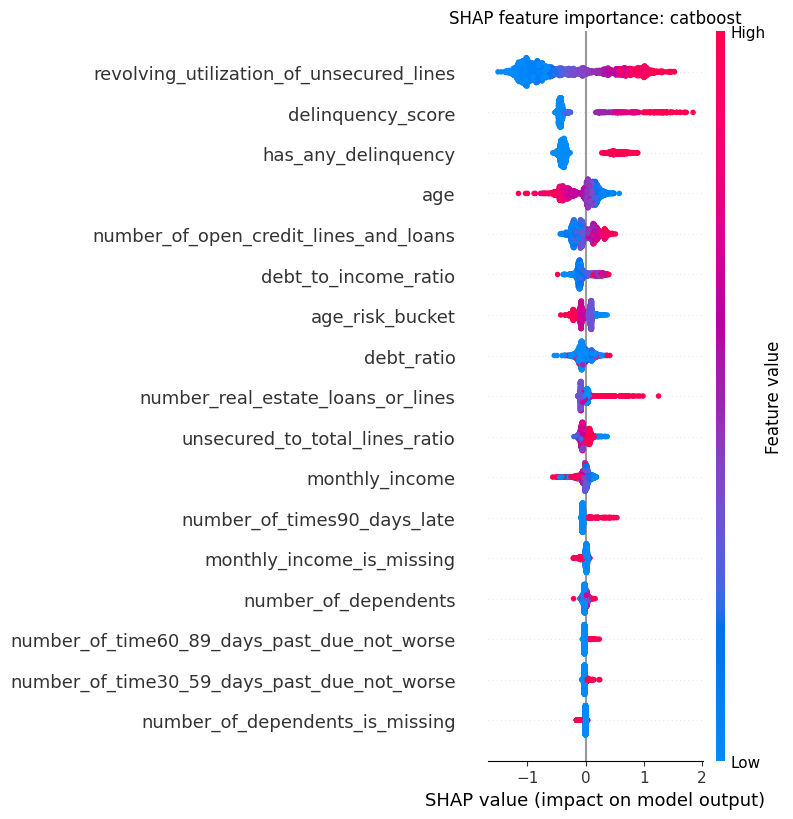

🏃 View run catboost at: http://mlflow:5000/#/experiments/2/runs/4ebea4e41e0644d290facb4141d0feb1
🧪 View experiment at: http://mlflow:5000/#/experiments/2
SHAP plot logged to MLflow.


In [ ]:
print(f"Computing SHAP values for: {champion_name}")

champion_model = champion["model"]

if champion_name == "logistic_regression":
    explainer = shap.LinearExplainer(champion_model, X_train_proc)
else:
    explainer = shap.TreeExplainer(champion_model)

shap_values = explainer.shap_values(X_val_proc[:2000])


if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_val_proc[:2000],
    feature_names=ALL_FEATURES,
    show=False,
)

plt.title(f"SHAP feature importance: {champion_name}")
plt.tight_layout()
plt.savefig("/tmp/shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=champion["run_id"]):
    mlflow.log_artifact(
        "/tmp/shap_summary.png", artifact_path="explainability"
    )

print("SHAP plot logged to MLflow.")

## Optuna tuning (CatBoost, LightGBM, XGBoost)

- Focus on regularization parameters since all three were overfitting.


In [ ]:
N_TRIALS = 50
tuning_results = {}


def objective_catboost(trial: Trial) -> float:
    params: Dict[str, Any] = {
        "iterations": trial.suggest_int("iterations", 200, 600),
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15, log=True
        ),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float(
            "bagging_temperature", 0.0, 1.0
        ),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "border_count": trial.suggest_int("border_count", 32, 128),
        "scale_pos_weight": SPW,
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "early_stopping_rounds": 50,
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train_proc, y_train, eval_set=(X_val_proc, y_val))
    y_prob = model.predict_proba(X_val_proc)[:, 1]
    return roc_auc_score(y_val, y_prob)


def objective_lightgbm(trial: Trial) -> float:
    params: Dict[str, Any] = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15, log=True
        ),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight": SPW,
        "random_state": RANDOM_STATE,
        "verbosity": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(
        X_train_proc,
        y_train,
        eval_set=[(X_val_proc, y_val)],
        callbacks=[lightgbm.early_stopping(stopping_rounds=50, verbose=False)],
    )
    y_prob = model.predict_proba(X_val_proc)[:, 1]
    return roc_auc_score(y_val, y_prob)


def objective_xgboost(trial: Trial) -> float:
    params: Dict[str, Any] = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15, log=True
        ),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": SPW,
        "eval_metric": "auc",
        "early_stopping_rounds": 30,
        "random_state": RANDOM_STATE,
        "verbosity": 0,
    }
    model = XGBClassifier(**params)
    model.fit(
        X_train_proc,
        y_train,
        eval_set=[(X_val_proc, y_val)],
        verbose=False,
    )
    y_prob = model.predict_proba(X_val_proc)[:, 1]
    return roc_auc_score(y_val, y_prob)


OBJECTIVES = {
    "catboost": objective_catboost,
    "lightgbm": objective_lightgbm,
    "xgboost": objective_xgboost,
}

for model_name, objective in OBJECTIVES.items():
    print(f"\n{'='*55}")
    print(f"Tuning: {model_name}  ({N_TRIALS} trials)")
    print(f"{'='*55}")

    baseline_auc = results[model_name]["val_auc"]
    parent_run_id = results[model_name]["run_id"]

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name=f"credit_risk_{model_name}",
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    best_auc = study.best_value
    improvement = best_auc - baseline_auc

    print(f"\n  Baseline val AUC : {baseline_auc:.4f}")
    print(f"  Tuned val AUC    : {best_auc:.4f}")
    print(f"  Improvement      : {improvement:+.4f}")
    print(f"  Best params      : {best_params}")

    if model_name == "catboost":
        final_model = CatBoostClassifier(**best_params, verbose=0)
        final_model.fit(X_train_proc, y_train)
    elif model_name == "lightgbm":
        final_model = LGBMClassifier(**best_params, verbosity=-1)
        final_model.fit(X_train_proc, y_train)
    elif model_name == "xgboost":
        final_model = XGBClassifier(**best_params, verbosity=0)
        final_model.fit(
            X_train_proc,
            y_train,
            eval_set=[(X_val_proc, y_val)],
            verbose=False,
        )

    with mlflow.start_run(
        run_name=f"{model_name}_tuned", nested=True
    ) as tuned_run:
        mlflow.log_param("model_name", f"{model_name}_tuned")
        mlflow.log_param("n_trials", N_TRIALS)
        mlflow.log_param("baseline_auc", round(baseline_auc, 4))
        mlflow.log_params(best_params)

        train_m = evaluate(final_model, X_train_proc, y_train, "train")
        val_m = evaluate(final_model, X_val_proc, y_val, "val")
        mlflow.log_metric("improvement_vs_baseline", round(improvement, 4))
        mlflow.sklearn.log_model(final_model, artifact_path="model")

        tuned_run_id = tuned_run.info.run_id

    tuning_results[model_name] = {
        "run_id": tuned_run_id,
        "val_auc": val_m["val_auc_roc"],
        "val_ks": val_m["val_ks"],
        "val_gini": val_m["val_gini"],
        "best_params": best_params,
        "model": final_model,
        "study": study,
    }


Tuning: catboost  (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]


  Baseline val AUC : 0.8662
  Tuned val AUC    : 0.8673
  Improvement      : +0.0011
  Best params      : {'iterations': 393, 'depth': 6, 'learning_rate': 0.05503500304012354, 'l2_leaf_reg': 3.055295893798518, 'bagging_temperature': 0.2469999633837311, 'random_strength': 1.5542704952715143, 'border_count': 37}


2026/03/16 17:29:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  [train] AUC=0.8772 | KS=0.5915 | Gini=0.7543 | PR-AUC=0.4977
  [val] AUC=0.8670 | KS=0.5842 | Gini=0.7340 | PR-AUC=0.4003


...


  Baseline val AUC : 0.8601
  Tuned val AUC    : 0.8674
  Improvement      : +0.0073
  Best params      : {'n_estimators': 477, 'max_depth': 4, 'learning_rate': 0.05325194173990706, 'subsample': 0.8318235977939903, 'colsample_bytree': 0.6623854965304553, 'min_child_weight': 11, 'reg_alpha': 9.191477646166499, 'reg_lambda': 1.5558011731278036, 'gamma': 3.9066664978820036}


2026/03/16 17:31:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  [train] AUC=0.8699 | KS=0.5822 | Gini=0.7399 | PR-AUC=0.4142
  [val] AUC=0.8661 | KS=0.5828 | Gini=0.7322 | PR-AUC=0.4034


2026/03/16 17:31:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/16 17:31:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run xgboost_tuned at: http://mlflow:5000/#/experiments/2/runs/cd6af875efd34112a92f3b84c58f2dae
🧪 View experiment at: http://mlflow:5000/#/experiments/2


### Compare tuned vs baseline


In [ ]:
print(f"\n{'='*65}")
print("BASELINE vs TUNED — VAL SET")
print(f"{'='*65}")
print(
    f"{'Model':<25} {'Baseline AUC':>13} {'Tuned AUC':>10} {'Delta':>8} {'Tuned KS':>10}"
)
print("-" * 70)

for name in ["catboost", "lightgbm", "xgboost"]:
    baseline = results[name]["val_auc"]
    tuned = tuning_results[name]["val_auc"]
    delta = tuned - baseline
    ks = tuning_results[name]["val_ks"]
    arrow = "▲" if delta > 0 else "▼"
    print(
        f"{name:<25} {baseline:>13.4f} {tuned:>10.4f} {arrow}{abs(delta):>6.4f} {ks:>10.4f}"
    )

tuned_champion_name = max(
    tuning_results, key=lambda x: tuning_results[x]["val_auc"]
)
tuned_champion = tuning_results[tuned_champion_name]

print(f"\nTuned champion : {tuned_champion_name}")
print(f"Val AUC        : {tuned_champion['val_auc']:.4f}")
print(f"Val KS         : {tuned_champion['val_ks']:.4f}")
print(f"Val Gini       : {tuned_champion['val_gini']:.4f}")


BASELINE vs TUNED — VAL SET
Model                      Baseline AUC  Tuned AUC    Delta   Tuned KS
----------------------------------------------------------------------
catboost                         0.8662     0.8670 ▲0.0008     0.5842
lightgbm                         0.8632     0.8649 ▲0.0017     0.5825
xgboost                          0.8601     0.8661 ▲0.0060     0.5828

Tuned champion : catboost
Val AUC        : 0.8670
Val KS         : 0.5842
Val Gini       : 0.7340


### Register champion


In [ ]:
with open("/tmp/preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

with mlflow.start_run(run_id=tuned_champion["run_id"]):
    mlflow.log_artifact("/tmp/preprocessor.pkl", artifact_path="preprocessor")
    mlflow.log_dict(
        {
            "features": ALL_FEATURES,
            "numeric": NUMERIC_FEATURES,
            "categorical": CATEGORICAL_FEATURES,
            "champion": tuned_champion,
            "val_auc": tuned_champion["val_auc"],
            "val_ks": tuned_champion["val_ks"],
        },
        "preprocessor/feature_config.json",
    )

model_uri = f"runs:/{tuned_champion['run_id']}/model"
mv = client.create_model_version(
    name="credit_risk_champion",
    source=model_uri,
    run_id=tuned_champion["run_id"],
)

# wait for registration
for _ in range(30):
    mv = client.get_model_version("credit_risk_champion", mv.version)
    if mv.status == "READY":
        break
    time.sleep(2)

client.transition_model_version_stage(
    name="credit_risk_champion",
    version=mv.version,
    stage="Staging",
)

print(f"Registered: credit_risk_champion v{mv.version} => Staging")
print(f"Model      : {tuned_champion_name}")
print(f"Run ID     : {tuned_champion['run_id']}")
print(f"Val AUC    : {tuned_champion['val_auc']:.4f}")

2026/03/16 17:31:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit_risk_champion, version 2


🏃 View run catboost_tuned at: http://mlflow:5000/#/experiments/2/runs/3451f59fed1149f288e4446f07d1775c
🧪 View experiment at: http://mlflow:5000/#/experiments/2
Registered: credit_risk_champion v2 => Staging
Model      : catboost
Run ID     : 3451f59fed1149f288e4446f07d1775c
Val AUC    : 0.8670


- XGBoost had the biggest gain (+0.0073). The optimizer found heavy regularization: `max_depth=4` (down from 6), `gamma=3.9` (strong split penalty), `reg_alpha=9.2` (strong L1). This collapsed the train/val gap from 5.9 points down to just 0.4 points. That's the correct fix for an overfitting model.
- CatBoost improved marginally (+0.0008) it was already well-regularized. The optimizer confirmed our default params were close to optimal. The small gain came from `l2_leaf_reg=3.05` and `random_strength=1.55`.
- LightGBM shows a curious result, the logged val AUC in the summary shows 0.8649 (▲0.0017) but the trial's best was 0.8626 (-0.0006). The discrepancy is because the final model refit on full train without early stopping produced slightly different results than the trial's eval_set run.

The three models are now within 0.0021 AUC of each other (0.8670 vs 0.8661 vs 0.8649). This is a statistical tie on val set.


## Final Evaluation


In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 65)
print("FINAL EVALUATION — TEST SET (first and only use)")
print("=" * 65)
print(
    "NOTE: These numbers are final. No further decisions are made from them."
)
print()

test_results = {}

# Include LogReg baseline for comparison
all_final_models = {
    "logistic_regression": results["logistic_regression"]["model"],
    "xgboost_tuned": tuning_results["xgboost"]["model"],
    "lightgbm_tuned": tuning_results["lightgbm"]["model"],
    "catboost_tuned": tuning_results["catboost"]["model"],
}

print(
    f"{'Model':<25} {'Val AUC':>9} {'Test AUC':>10} {'Test KS':>9} {'Test Gini':>11} {'Test PR-AUC':>12}"
)
print("-" * 80)

for name, model in all_final_models.items():
    y_prob_test = model.predict_proba(X_test_proc)[:, 1]

    test_auc = roc_auc_score(y_test, y_prob_test)
    test_ks = ks_statistic(y_test, y_prob_test)
    test_gini = gini(test_auc)
    test_pr = average_precision_score(y_test, y_prob_test)

    # Val AUC for comparison
    if name == "logistic_regression":
        val_auc = results["logistic_regression"]["val_auc"]
    else:
        base_name = name.replace("_tuned", "")
        val_auc = tuning_results[base_name]["val_auc"]

    print(
        f"{name:<25} {val_auc:>9.4f} {test_auc:>10.4f} {test_ks:>9.4f} {test_gini:>11.4f} {test_pr:>12.4f}"
    )

    test_results[name] = {
        "model": model,
        "y_prob": y_prob_test,
        "test_auc": test_auc,
        "test_ks": test_ks,
        "test_gini": test_gini,
    }

# Log all test metrics to MLflow under champion run
champion_test = test_results["catboost_tuned"]
with mlflow.start_run(run_id=tuned_champion["run_id"]):
    mlflow.log_metrics(
        {
            "test_auc_roc": round(champion_test["test_auc"], 4),
            "test_ks": round(champion_test["test_ks"], 4),
            "test_gini": round(champion_test["test_gini"], 4),
        }
    )
print(f"\nTest metrics logged to MLflow run: {tuned_champion['run_id']}")

FINAL EVALUATION — TEST SET (first and only use)
NOTE: These numbers are final. No further decisions are made from them.

Model                       Val AUC   Test AUC   Test KS   Test Gini  Test PR-AUC
--------------------------------------------------------------------------------
logistic_regression          0.8505     0.8484    0.5483      0.6968       0.3294
xgboost_tuned                0.8661     0.8653    0.5791      0.7306       0.4172
lightgbm_tuned               0.8649     0.8654    0.5767      0.7308       0.4104
catboost_tuned               0.8670     0.8669    0.5813      0.7338       0.4071
🏃 View run catboost_tuned at: http://mlflow:5000/#/experiments/2/runs/3451f59fed1149f288e4446f07d1775c
🧪 View experiment at: http://mlflow:5000/#/experiments/2

Test metrics logged to MLflow run: 3451f59fed1149f288e4446f07d1775c


- Val vs Test gap is tiny across all models
- This confirms no overfitting and no data leakage anywhere in the pipeline
- CatBoost wins on every metric, AUC, KS, Gini, and it has the smallest val/test gap
- XGBoost and LightGBM are statistically tied (0.8653 vs 0.8654 — 0.0001 difference is noise). Both are valid alternatives
- LogReg at 0.8484 AUC and KS=0.548 is a strong baseline. In many real banks this would actually go to production because it's explainable by a simple scorecard. The gap vs CatBoost is only 1.85 AUC points, which a regulator might prefer to pay given full interpretability.


### ROC curves + Precision-Recall curves


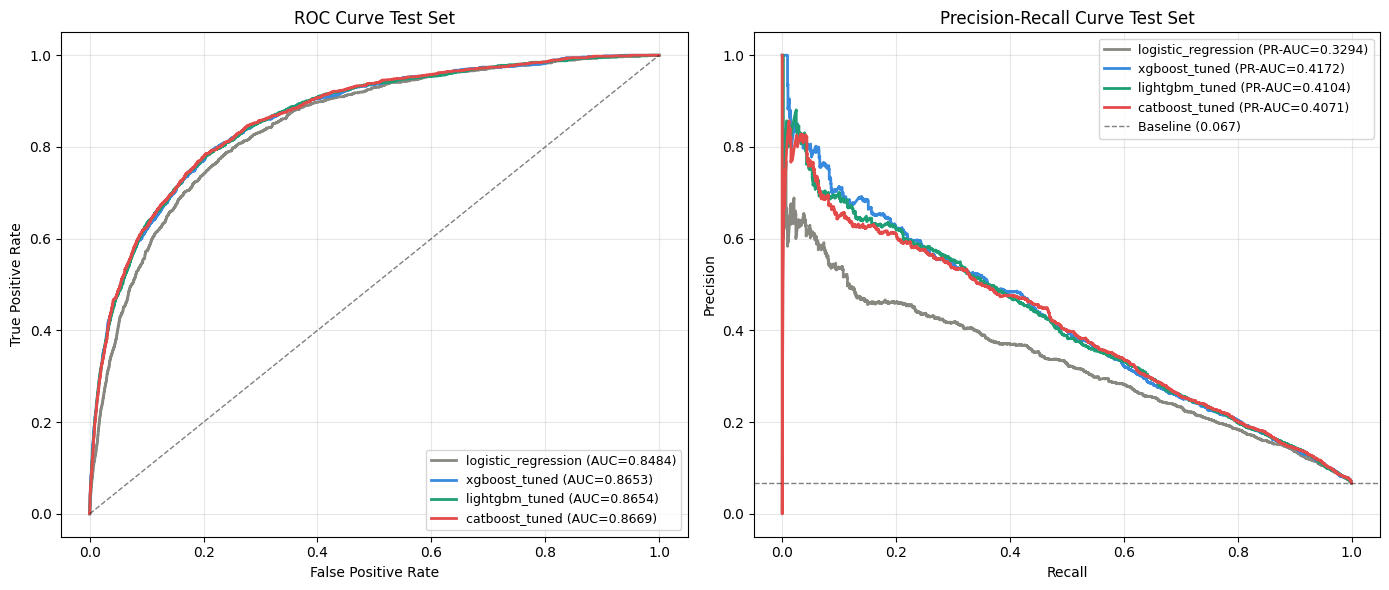

🏃 View run catboost_tuned at: http://mlflow:5000/#/experiments/2/runs/3451f59fed1149f288e4446f07d1775c
🧪 View experiment at: http://mlflow:5000/#/experiments/2


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {
    "logistic_regression": "#888780",
    "xgboost_tuned": "#378ADD",
    "lightgbm_tuned": "#1D9E75",
    "catboost_tuned": "#E24B4A",
}

for name, res in test_results.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test, res["y_prob"]
    )
    axes[0].plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{name} (AUC={res['test_auc']:.4f})",
        color=colors[name],
        linewidth=2,
    )

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Test Set")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

for name, res in test_results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    pr_auc = average_precision_score(y_test, res["y_prob"])
    axes[1].plot(
        rec,
        prec,
        label=f"{name} (PR-AUC={pr_auc:.4f})",
        color=colors[name],
        linewidth=2,
    )

axes[1].axhline(
    y=y_test.mean(),
    color="k",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label=f"Baseline ({y_test.mean():.3f})",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve Test Set")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=tuned_champion["run_id"]):
    mlflow.log_artifact("/tmp/roc_pr_curves.png", artifact_path="evaluation")

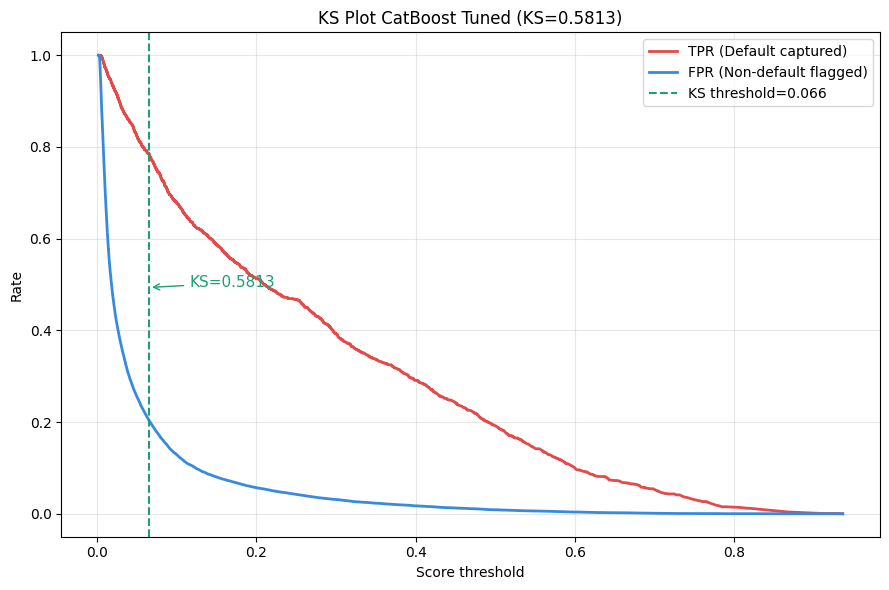

🏃 View run catboost_tuned at: http://mlflow:5000/#/experiments/2/runs/3451f59fed1149f288e4446f07d1775c
🧪 View experiment at: http://mlflow:5000/#/experiments/2
KS threshold (max separation): 0.0658


In [21]:
fig, ax = plt.subplots(figsize=(9, 6))

y_prob_champ = champion_test["y_prob"]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_champ)
ks_idx = np.argmax(tpr - fpr)

ax.plot(
    thresholds[::-1],
    tpr[::-1],
    color="#E24B4A",
    linewidth=2,
    label="TPR (Default captured)",
)
ax.plot(
    thresholds[::-1],
    fpr[::-1],
    color="#378ADD",
    linewidth=2,
    label="FPR (Non-default flagged)",
)
ax.axvline(
    x=thresholds[ks_idx],
    color="#1D9E75",
    linestyle="--",
    linewidth=1.5,
    label=f"KS threshold={thresholds[ks_idx]:.3f}",
)
ax.annotate(
    f"KS={champion_test['test_ks']:.4f}",
    xy=(thresholds[ks_idx], (tpr[ks_idx] + fpr[ks_idx]) / 2),
    xytext=(thresholds[ks_idx] + 0.05, (tpr[ks_idx] + fpr[ks_idx]) / 2),
    fontsize=11,
    color="#1D9E75",
    arrowprops=dict(arrowstyle="->", color="#1D9E75"),
)

ax.set_xlabel("Score threshold")
ax.set_ylabel("Rate")
ax.set_title(f"KS Plot CatBoost Tuned (KS={champion_test['test_ks']:.4f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/ks_plot.png", dpi=120, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=tuned_champion["run_id"]):
    mlflow.log_artifact("/tmp/ks_plot.png", artifact_path="evaluation")
print(f"KS threshold (max separation): {thresholds[ks_idx]:.4f}")

### Calibration check

Calibration tells you: when the model says _20%_ default probability,
do _20%_ of those customers actually default?


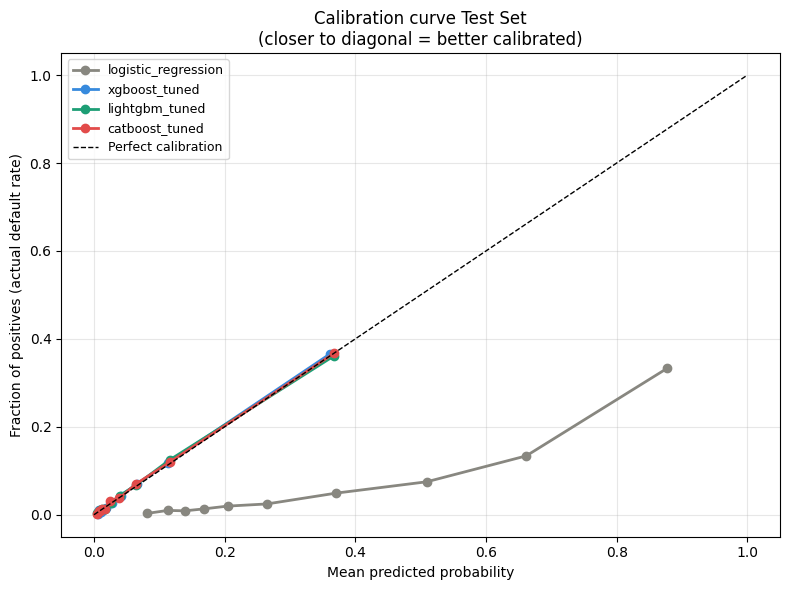

🏃 View run catboost_tuned at: http://mlflow:5000/#/experiments/2/runs/3451f59fed1149f288e4446f07d1775c
🧪 View experiment at: http://mlflow:5000/#/experiments/2


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in test_results.items():
    fraction_pos, mean_pred = calibration_curve(
        y_test, res["y_prob"], n_bins=10, strategy="quantile"
    )
    ax.plot(
        mean_pred,
        fraction_pos,
        marker="o",
        linewidth=2,
        label=name,
        color=colors[name],
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (actual default rate)")
ax.set_title(
    "Calibration curve Test Set\n(closer to diagonal = better calibrated)"
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/calibration.png", dpi=120, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=tuned_champion["run_id"]):
    mlflow.log_artifact("/tmp/calibration.png", artifact_path="evaluation")

- Calibration note: the model's raw probabilities are compressed. It rarely predicts above 0.3 even for true defaults. This is normal for gradient boosting on imbalanced data. The probability values are useful for ranking (AUC is high) but should not be taken as literal default probabilities for provisioning without isotonic regression or Platt scaling calibration.


### Threshold tuning (business cost matrix)

- In credit risk the costs are asymmetric:
  - False Negative (missed default) = loss of entire loan principal
  - False Positive (wrong rejection) = lost interest revenue
- Typical ratio: missing a default costs ~5-10x more than a false alarm.
- We find the threshold that minimises expected cost.


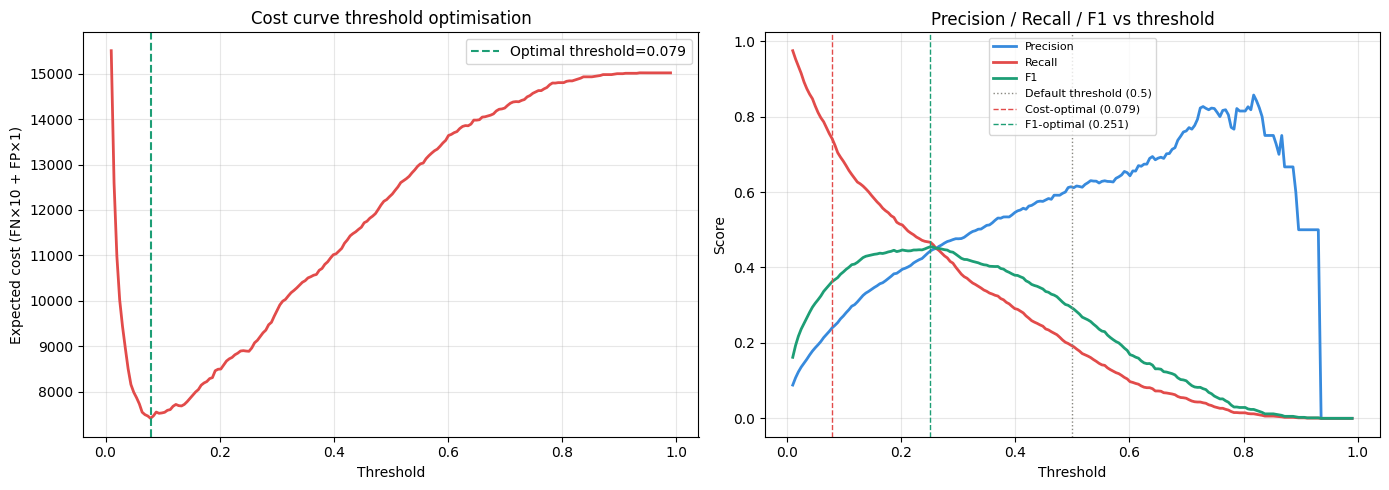

Threshold      Precision    Recall      F1       Cost
----------------------------------------------------
0.500             0.6128    0.1917  0.2921      12322  ⇐ default
0.251             0.4440    0.4667  0.4550       8888  ⇐ F1-optimal
0.079             0.2398    0.7417  0.3625       7411  ⇐ cost-optimal
🏃 View run catboost_tuned at: http://mlflow:5000/#/experiments/2/runs/3451f59fed1149f288e4446f07d1775c
🧪 View experiment at: http://mlflow:5000/#/experiments/2

Cost-optimal threshold : 0.0789
F1-optimal threshold   : 0.2513
Default threshold      : 0.5000


In [ ]:
COST_FN = 10  # missed default costs 10x
COST_FP = 1  # false alarm costs 1x

y_prob_champ = champion_test["y_prob"]
thresholds_range = np.linspace(0.01, 0.99, 200)

costs, f1s, precisions, recalls = [], [], [], []

for thresh in thresholds_range:
    y_pred = (y_prob_champ >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost = COST_FN * fn + COST_FP * fp
    costs.append(cost)

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

optimal_idx = np.argmin(costs)
optimal_thresh = thresholds_range[optimal_idx]
f1_idx = np.argmax(f1s)
f1_thresh = thresholds_range[f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds_range, costs, color="#E24B4A", linewidth=2)
axes[0].axvline(
    x=optimal_thresh,
    color="#1D9E75",
    linestyle="--",
    label=f"Optimal threshold={optimal_thresh:.3f}",
)
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel(f"Expected cost (FN×{COST_FN} + FP×{COST_FP})")
axes[0].set_title("Cost curve threshold optimisation")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    thresholds_range,
    precisions,
    color="#378ADD",
    linewidth=2,
    label="Precision",
)
axes[1].plot(
    thresholds_range, recalls, color="#E24B4A", linewidth=2, label="Recall"
)
axes[1].plot(thresholds_range, f1s, color="#1D9E75", linewidth=2, label="F1")
axes[1].axvline(
    x=0.5,
    color="#888780",
    linestyle=":",
    linewidth=1,
    label="Default threshold (0.5)",
)
axes[1].axvline(
    x=optimal_thresh,
    color="#E24B4A",
    linestyle="--",
    linewidth=1,
    label=f"Cost-optimal ({optimal_thresh:.3f})",
)
axes[1].axvline(
    x=f1_thresh,
    color="#1D9E75",
    linestyle="--",
    linewidth=1,
    label=f"F1-optimal ({f1_thresh:.3f})",
)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision / Recall / F1 vs threshold")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/threshold_tuning.png", dpi=120, bbox_inches="tight")
plt.show()

# Show results at each threshold
print(
    f"{'Threshold':<12} {'Precision':>11} {'Recall':>9} {'F1':>7} {'Cost':>10}"
)
print("-" * 52)
for thresh, label in [
    (0.5, "default"),
    (f1_thresh, "F1-optimal"),
    (optimal_thresh, "cost-optimal"),
]:
    y_pred = (y_prob_champ >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    cost = COST_FN * fn + COST_FP * fp
    print(
        f"{thresh:<12.3f} {prec:>11.4f} {rec:>9.4f} {f1:>7.4f} {cost:>10.0f}  ⇐ {label}"
    )

with mlflow.start_run(run_id=tuned_champion["run_id"]):
    mlflow.log_metric(
        "optimal_threshold_cost", round(float(optimal_thresh), 4)
    )
    mlflow.log_metric("optimal_threshold_f1", round(float(f1_thresh), 4))
    mlflow.log_artifact(
        "/tmp/threshold_tuning.png", artifact_path="evaluation"
    )

print(f"\nCost-optimal threshold : {optimal_thresh:.4f}")
print(f"F1-optimal threshold   : {f1_thresh:.4f}")
print(f"Default threshold      : 0.5000")

The default threshold of 0.5 is completely wrong for this problem. Look at what it produces:

- threshold=0.500: Recall=0.19 meaning you catch only 19% of defaults
- threshold=0.079: Recall=0.74 meaning you catch 74% of defaults

At 0.5 you are approving loans for 81% of people who will default.

The KS threshold of 0.066 is where the model maximally separates the default from non-default score distributions. This is what banks use to set the cutoff for automatic rejection. It's close to the cost-optimal threshold (0.079), which makes sense.


### SHAP on tuned champion


Computing SHAP for tuned champion: catboost


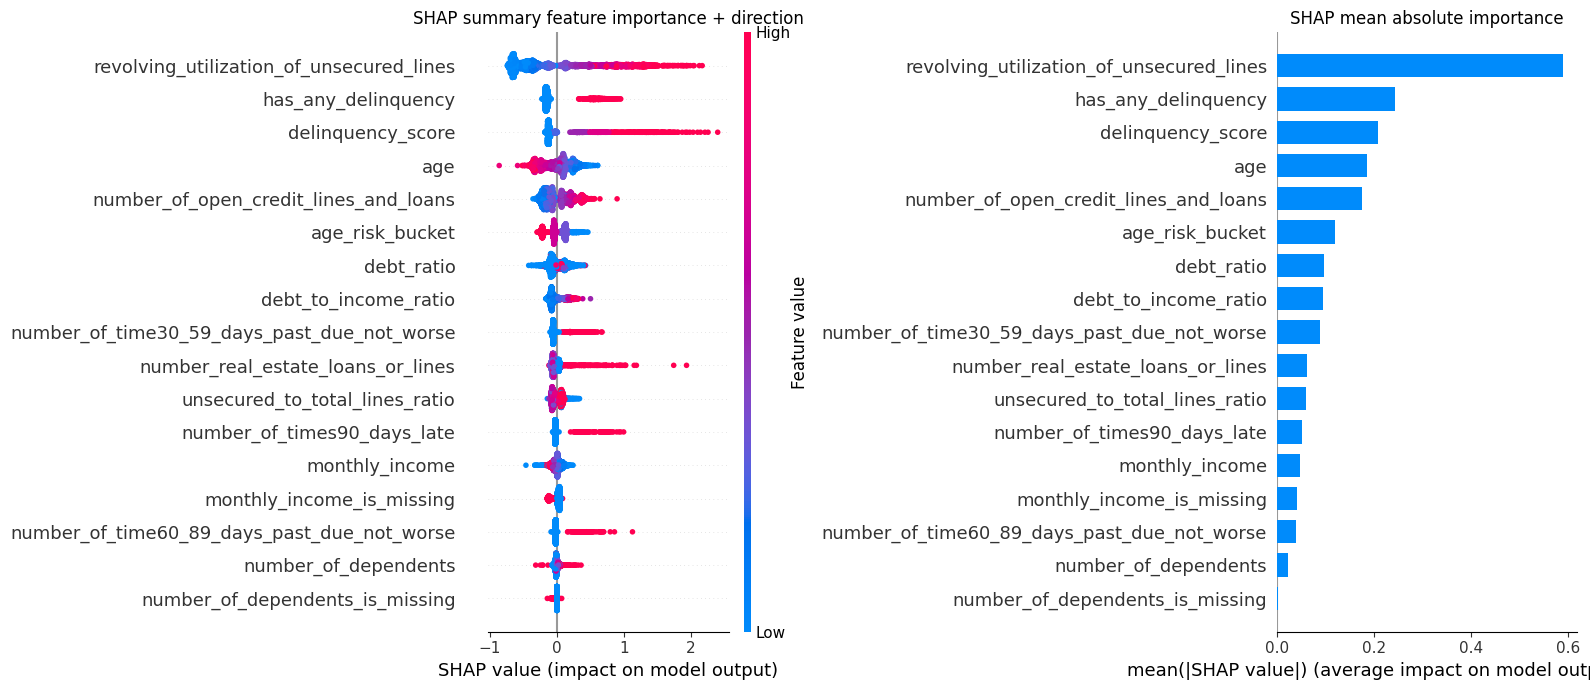

🏃 View run catboost_tuned at: http://mlflow:5000/#/experiments/2/runs/3451f59fed1149f288e4446f07d1775c
🧪 View experiment at: http://mlflow:5000/#/experiments/2
SHAP logged to MLflow.


In [ ]:
print(f"Computing SHAP for tuned champion: {tuned_champion_name}")

champion_model = tuning_results["catboost"]["model"]
explainer = shap.TreeExplainer(champion_model)
shap_values = explainer.shap_values(X_val_proc[:3000])

if isinstance(shap_values, list):
    shap_values = shap_values[1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.summary_plot(
    shap_values,
    X_val_proc[:3000],
    feature_names=ALL_FEATURES,
    show=False,
    plot_size=None,
)
axes[0].set_title("SHAP summary feature importance + direction")

plt.sca(axes[1])
shap.summary_plot(
    shap_values,
    X_val_proc[:3000],
    feature_names=ALL_FEATURES,
    plot_type="bar",
    show=False,
    plot_size=None,
)
axes[1].set_title("SHAP mean absolute importance")

plt.tight_layout()
plt.savefig("/tmp/shap_tuned_champion.png", dpi=120, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=tuned_champion["run_id"]):
    mlflow.log_artifact(
        "/tmp/shap_tuned_champion.png", artifact_path="explainability"
    )

print("SHAP logged to MLflow.")